In [1]:
# 변수의 shape, type, value 확인
def p(var,_name="") :
    if _name != "" : print(f'<<{_name}>>')
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}')

def pst(_x,_name=""):
    print(f'<<{_name}>> Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'<<{_name}>> Shape{_x.shape}')

# LangFuse에서 Prompt Management 사용해 보기

In [2]:
%%time
!pip install -q langgraph==0.6.10 langchain==0.3.27 langchain-openai==0.3.35 langchain-teddynote==0.5.1 langfuse opentelemetry-instrumentation-openai
# google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.

CPU times: user 1.25 s, sys: 204 ms, total: 1.45 s
Wall time: 4.06 s


In [3]:
!pip list | grep -E "langchain|langgraph|langchain-openai|langchain-teddynote|langfuse|opentelemetry-instrumentation-openai"
# 2510
# langchain                             0.3.27
# langchain-core                        0.3.78
# langchain-openai                      0.3.35
# langchain-teddynote                   0.5.1
# langchain-text-splitters              0.3.11
# langgraph                             0.6.10
# langgraph-checkpoint                  2.1.2
# langgraph-prebuilt                    0.6.4
# langgraph-sdk                         0.2.9

# 2511
# langchain                                0.3.27
# langchain-core                           0.3.79
# langchain-openai                         0.3.35
# langchain-teddynote                      0.5.1
# langchain-text-splitters                 0.3.11
# langfuse                                 3.10.0
# langgraph                                0.6.10
# langgraph-checkpoint                     2.1.2
# langgraph-prebuilt                       0.6.5
# langgraph-sdk                            0.2.9
# opentelemetry-instrumentation-openai     0.48.1


langchain                                0.3.27
langchain-core                           0.3.79
langchain-openai                         0.3.35
langchain-teddynote                      0.5.1
langchain-text-splitters                 0.3.11
langfuse                                 3.10.0
langgraph                                0.6.10
langgraph-checkpoint                     2.1.2
langgraph-prebuilt                       0.6.5
langgraph-sdk                            0.2.9
opentelemetry-instrumentation-openai     0.48.1


In [4]:
## env 설정 이후에 langchain_openai, langgraph를 import 해야 함 ##

import os, requests
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

In [5]:
os.environ["LANGFUSE_PUBLIC_KEY"] = userdata.get('LANGFUSE_PUBLIC_KEY')
os.environ["LANGFUSE_SECRET_KEY"] = userdata.get('LANGFUSE_SECRET_KEY')
os.environ["LANGFUSE_HOST"] = "https://us.cloud.langfuse.com"

In [6]:
# 헬스체크
r = requests.get(f"{os.environ['LANGFUSE_HOST']}/api/public/health", timeout=10)
print("LangFuse health:", r.status_code, r.text[:200])

LangFuse health: 200 {"status":"OK","version":"3.132.0"}


LangFuse Cloud 접속 **개인계정** :
https://us.cloud.langfuse.com      

In [7]:
from typing import TypedDict, List
from langchain_openai import ChatOpenAI

from langchain_teddynote.graphs import visualize_graph
from langchain.prompts import PromptTemplate
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, END

from langfuse.langchain import CallbackHandler
from langfuse import get_client

# import warnings
# warnings.filterwarnings("ignore", category=UserWarning)

## 절차 정리  
1. UI/SDK로 prompt 생성하고(버전을 자동화)  
2. label('test','production-a'등)로 배포 관리  
3. run time에서 label, version으로 prompt 가져와 실행 + trace에 prompt정보 삽입(관리용)   

    photo_litho.rewrite  
    prod-a
    너는 반도체 공정 전문가야.
    아래 질의를 검색 친화적으로 1줄로 재작성하고 동의어/영문 병기를 포함해줘.
    질의: {{query}}
    출력은 한 줄.

    prod-b
    너는 반도체 공정 전문가야.
    아래 질의를 검색 친화적으로 두 줄로 재작성하고 유사한 키워드 추가 및 동의어/영문 병기를 포함해줘.
    질의: {{query}}
    출력은 두 줄.

    photo_litho.answer   
    prod-a  
    질문: {{query}}
    근거:
    {{docs_bulleted}}
    핵심만 3문장 이내로 한국어로 정확하게 설명해줘.

    prod-b
    질문: {{query}}
    근거:
    {{docs_bulleted}}
    근거를 바탕으로 질문에 대한 핵심 답변을 3문장 이내로 한국어로 정확하게 설명해줘.


In [8]:
# LangFuse Tracer 활성화
lf_handler = CallbackHandler()

def make_base_llm(callback_handler, model_name="gpt-4o-mini", temperature=0):
    # 필요 시 gpt-5-mini 등으로 교체
    return ChatOpenAI(model=model_name, temperature=temperature, callbacks=[callback_handler])

def make_local_llm(callback_handler, model_name, temperature=0):
    pass
    return

In [9]:
## 다양한 LLM 비교 실험 할때 ##
LLM_REF = {"base_llm": None,
           "local_llm": None }

LLM_REF["base_llm"] = make_base_llm(lf_handler)

def use_llm(llm: str):
    return LLM_REF[llm]

# llm = use_llm("base_llm")

## 프롬프트 A/B 전환 유틸리티   
( production label로 가져오되 실패 시 내장 값 폴백 )

In [11]:
# 다음 Prompt Name을 label "prod-a","prod-b"로 운영
PROMPT_NAME_REWRITE = "photo_litho.rewrite"
PROMPT_NAME_ANSWER  = "photo_litho.answer"

# 내장(fallback) 프롬프트
FALLBACK_REWRITE = (
    "너는 반도체 공정 전문가야. 다음 질의를 검색 친화적으로 리라이트하고 "
    "동의어를 포함해줘.\n질의: {query}\n출력은 한 줄." )
FALLBACK_ANSWER = (
    "질문: {query}\n근거:\n{docs_bulleted}\n\n"
    "핵심만 간략하게 설명해줘." )

lf = get_client() # prompts 가져 오기 위해 필요

def lf_text_prompt(p) -> str:
    """LangFuse Prompt 객체 -> LangChain용 문자열
       (chat 타입이면 예외; text type 전용)"""
    tmpl = p.get_langchain_prompt()   # 3.x 표준
    if not isinstance(tmpl, str):
        raise TypeError("chat type 프롬프트입니다. text type만 지원합니다.")
    # {{var}} → {var}
    return tmpl.replace("{{","{").replace("}}","}")

def fetch_prompt_text(name: str, label: str, fallback_text: str) -> tuple[str, str]:
    """LangFuse(name, label)에서 텍스트 프롬프트를 가져오거나, 실패 시 fallback 사용.
       return: (text, source) # source: 'lf:<label>' or 'fallback'"""
    try:
        p = lf.get_prompt(name, label=label)
        text = lf_text_prompt(p)
        return text, f"lf:{label}"
    except Exception:
        return fallback_text, "fallback"

def build_prompt_pack(variant_label: str):
    """variant_label = 'prod-a' | 'prod-b'"""
    rewrite_text, rewrite_src = fetch_prompt_text(PROMPT_NAME_REWRITE, variant_label, FALLBACK_REWRITE)
    answer_text,  answer_src  = fetch_prompt_text(PROMPT_NAME_ANSWER,  variant_label, FALLBACK_ANSWER)
    return {
        "variant": variant_label,
        "rewrite_text": rewrite_text,
        "answer_text": answer_text,
        "sources": {"rewrite": rewrite_src, "answer": answer_src}, }

In [16]:
print( build_prompt_pack("prod-a") ), print("="*10)
print( build_prompt_pack("prod-b") ), print("="*10)
print( build_prompt_pack("prod") )

{'variant': 'prod-a', 'rewrite_text': '너는 반도체 공정 전문가야.\n아래 질의를 검색 친화적으로 1줄로 리라이트하고 동의어/영문 병기를 포함해줘.\n질의: {query}\n출력은 한 줄.', 'answer_text': '질문: {query}\n근거:\n{docs_bulleted}\n\n핵심만 3문장 이내로 한국어로 정확하게 설명해줘.\n', 'sources': {'rewrite': 'lf:prod-a', 'answer': 'lf:prod-a'}}
{'variant': 'prod-b', 'rewrite_text': '너는 반도체 공정 전문가야.\n아래 질의를 검색 친화적으로 두 줄로 재작성하고 유사한 키워드 추가 및 동의어/영문 병기를 포함해줘.\n질의: {query}\n출력은 두 줄.', 'answer_text': '질문: {query}\n근거:\n{docs_bulleted}\n\n근거를 바탕으로 질문에 대한 핵심 답변을 3문장 이내로 한국어로 정확하게 설명해줘.\n', 'sources': {'rewrite': 'lf:prod-b', 'answer': 'lf:prod-b'}}
{'variant': 'prod', 'rewrite_text': '너는 반도체 공정 전문가야.\n아래 질의를 검색 친화적으로 1줄로 리라이트하고 동의어/영문 병기를 포함해줘.\n질의: {query}\n출력은 한 줄.', 'answer_text': '질문: {query}\n근거:\n{docs_bulleted}\n\n핵심만 3문장 이내로 한국어로 정확하게 설명해줘.\n', 'sources': {'rewrite': 'lf:prod', 'answer': 'lf:prod'}}


    {'variant': 'prod-a',
    'rewrite_text': '너는 반도체 공정 전문가야.\n아래 질의를 검색 친화적으로 1줄로 리라이트하고 동의어/영문 병기를 포함해줘.\n질의: {query}\n출력은 한 줄.',  
    'answer_text': '질문: {query}\n근거:\n{docs_bulleted}\n\n핵심만 3문장 이내로 한국어로 정확하게 설명해줘.\n',   
    'sources': {'rewrite': 'lf:prod-a', 'answer': 'lf:prod-a'}}
    ==========
    {'variant': 'prod-b',  
    'rewrite_text': '너는 반도체 공정 전문가야.\n아래 질의를 검색 친화적으로 두 줄로 재작성하고 유사한 키워드 추가 및 동의어/영문 병기를 포함해줘.\n질의: {query}\n출력은 두 줄.',  
    'answer_text': '질문: {query}\n근거:\n{docs_bulleted}\n\n근거를 바탕으로 질문에 대한 핵심 답변을 3문장 이내로 한국어로 정확하게 설명해줘.\n',  
    'sources': {'rewrite': 'lf:prod-b', 'answer': 'lf:prod-b'}}
    ==========
    {'variant': 'prod',   
    'rewrite_text': '너는 반도체 공정 전문가야. 다음 질의를 검색 친화적으로 리라이트하고 동의어를 포함해줘.\n질의: {query}\n출력은 한 줄.',   
    'answer_text': '질문: {query}\n근거:\n{docs_bulleted}\n\n핵심만 간략하게 설명해줘.',   
    'sources': {'rewrite': 'fallback', 'answer': 'fallback'}}


## LangGraph에서 prompt set 변경 하기   

### 그래프 상태 / BD 검색 함수 정의

In [17]:
from typing import TypedDict, List
import time

class AgentState(TypedDict, total=False):
    query: str
    rewritten_query: str
    docs: List[str]
    tool_output: str
    quality_ok: bool
    retries: int
    answer: str
    prompts: dict  # build_prompt_pack 결과

# 아주 단순한 "DB" 흉내
FAKE_DB = {
    "포토리소그래피": [
        "포토레지스트(PR)를 웨이퍼에 코팅하고, 마스크를 통해 노광(Exposure)한다.",
        "현상(Develop)으로 노광된 영역을 제거하여 패턴을 형성한다.",
        "에칭(Etch)과 스트립(Strip) 단계를 통해 회로 패턴을 완성한다.",
    ],
    "식각": [
        "식각(Etch)은 원하는 패턴만 남기도록 재료를 제거하는 과정이다.",
        "건식식각(플라즈마)과 습식식각(액체 화학)을 사용한다.",
    ],
}

def retrieve_from_fake_db(q: str) -> List[str]:
    time.sleep(0.05)  # 지연 흉내
    hits = []
    for k, docs in FAKE_DB.items():
        if k in q:
            hits.extend(docs)
    return hits[:5]

### 노드 정의   
(입력→리라이트→검색→품질검증→재시도/답변/폴백)

In [37]:
### Rewrite query / answer node 에서 prompt 변경 ###

# state의 query, prompt는 invoke시점에 저장
def input_node(state: AgentState) -> AgentState:
    return { "retries": state.get("retries", 0) }

### Rewrite query (Prompt 변경 적용)
def rewrite_query_node(state: AgentState) -> AgentState:
    prompt_text = state["prompts"]["rewrite_text"]
    user_q = state["query"]
    # 단일 사용자 메시지로 전달(프롬프트에 시스템 역할까지 포함되어 있어도 됨)
    msg = prompt_text.format(query=user_q)
    resp = llm.invoke([{"role":"user","content": msg}])
    return {"rewritten_query": resp.content.strip()}

# DB 검색 + 간단 요약
def retrieve_node(state: AgentState) -> AgentState:
    q = state.get("rewritten_query") or state["query"]
    docs = retrieve_from_fake_db(q)
    tool_output = "\n".join(f"- {d}" for d in docs) if docs else "(no hits)"

    # 검색결과 요약(LLM) — Trace에서 보기 위한 dummy
    summary_prompt = f"다음 검색 결과를 한 문장으로 요약:\n{tool_output}"
    resp = llm.invoke([{"role":"system","content":"너는 반도체 공정 요약가야."},
                       {"role":"user","content": summary_prompt}])

    return {"docs": docs, "tool_output": resp.content.strip()}

# 답변 품질 검증(LLM yes/no)
def quality_check_node(state: AgentState) -> AgentState:
    q = state["query"]
    docs = state.get("docs", [])
    if not docs:
        return {"quality_ok": False}

    prompt = f"쿼리: {q}\n근거:\n- " + "\n- ".join(docs) + "\n\n충분하면 yes, 아니면 no."
    resp = llm.invoke([{"role":"system","content":"너는 품질 검사자야. yes/no만 출력."},
                       {"role":"user","content": prompt}])
    ok = "yes" in resp.content.lower()
    return {"quality_ok": ok}

# Refine query : query 보강
def refine_query_node(state: AgentState) -> AgentState:
    user_q = state["query"]
    prev = state.get("rewritten_query") or user_q
    prompt = f"기존 질의: {prev}\n키워드 보강/동의어/한영 병기를 포함해 한 줄로 리라이트."
    resp = llm.invoke([{"role":"system","content":"너는 검색 전문가야."},
                       {"role":"user","content": prompt}])
    return {"rewritten_query": resp.content.strip(), "retries": state.get("retries",0)+1}

### 최종 답변 정리 (prompt 변경 적용)
def answer_node(state: AgentState) -> AgentState:
    q = state["query"]
    docs = state.get("docs", [])
    docs_bulleted = "".join([f"- {d}\n" for d in docs]) if docs else "- (no evidence)\n"
    prompt_text = state["prompts"]["answer_text"]
    msg = prompt_text.format(query=q, docs_bulleted=docs_bulleted)
    resp = llm.invoke([{"role":"user","content": msg}])
    return {"answer": resp.content.strip()}

# Fall back(반복 실패 시)
def fallback_answer_node(state: AgentState) -> AgentState:
    q = state["query"]
    prompt = f"질문: {q}\n근거 부족. 일반적인 개요를 2~3문장으로 제공."
    resp = llm.invoke([{"role":"system","content":"너는 반도체 공정 전문가야."},
                       {"role":"user","content": prompt}])
    return {"answer": resp.content.strip()}

### 그래프구성  

In [38]:
from langgraph.graph import StateGraph, END

def route_after_quality(state: AgentState) -> str:
    if state.get("quality_ok"):
        return "ok"
    if state.get("retries",0) < 2:
        return "refine"
    return "fallback"

workflow = StateGraph(AgentState)
workflow.set_entry_point("input")

workflow.add_node("input",   input_node)
workflow.add_node("rewrite", rewrite_query_node)
workflow.add_node("retrieve",retrieve_node)
workflow.add_node("quality", quality_check_node)
workflow.add_node("refine",  refine_query_node)
workflow.add_node("answer",  answer_node)
workflow.add_node("fallback",fallback_answer_node)

workflow.add_edge("input", "rewrite")
workflow.add_edge("rewrite", "retrieve")
workflow.add_edge("retrieve", "quality")

workflow.add_conditional_edges(
    "quality",
    route_after_quality,
    {"ok":"answer", "refine":"refine", "fallback":"fallback"}
)
workflow.add_edge("refine", "retrieve")
workflow.add_edge("answer", END)
workflow.add_edge("fallback", END)

app = workflow.compile()

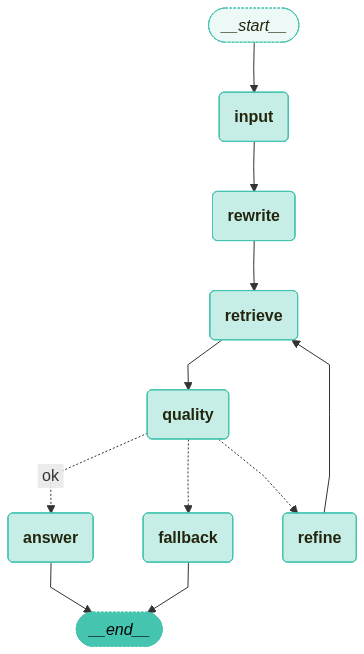

In [39]:
visualize_graph(app)

### A/B 실행 (prod-a vs prod-b) — 태그/메타데이터로 대시보드 비교

In [40]:
llm = use_llm("base_llm")

def run_once(query: str, variant: str):
    prompt_pack = build_prompt_pack(variant)
    res = app.invoke(
        {"query": query, "prompts": prompt_pack},
        config={
            "callbacks": [lf_handler],
            "run_name": f"Graph-AB-{variant}",

            "metadata": {
                "variant": variant,
                "rewrite_source": prompt_pack["sources"]["rewrite"],
                "answer_source":  prompt_pack["sources"]["answer"],

                # 대시보드 필터용 태그
                "langfuse_tags": ["graph", "ab", f"variant:{variant}",
                                  f"rewrite:{prompt_pack['sources']['rewrite']}",
                                  f"answer:{prompt_pack['sources']['answer']}"],

                # 사용자/세션 식별자
                "langfuse_user_id": "sunny",
                "langfuse_session_id": "colab-ab-demo",
            },
        }
    )
    return res

In [22]:
build_prompt_pack("prod-a")

{'variant': 'prod-a',
 'rewrite_text': '너는 반도체 공정 전문가야.\n아래 질의를 검색 친화적으로 1줄로 리라이트하고 동의어/영문 병기를 포함해줘.\n질의: {query}\n출력은 한 줄.',
 'answer_text': '질문: {query}\n근거:\n{docs_bulleted}\n\n핵심만 3문장 이내로 한국어로 정확하게 설명해줘.\n',
 'sources': {'rewrite': 'lf:prod-a', 'answer': 'lf:prod-a'}}

In [23]:
build_prompt_pack("prod-b")

{'variant': 'prod-b',
 'rewrite_text': '너는 반도체 공정 전문가야.\n아래 질의를 검색 친화적으로 두 줄로 재작성하고 유사한 키워드 추가 및 동의어/영문 병기를 포함해줘.\n질의: {query}\n출력은 두 줄.',
 'answer_text': '질문: {query}\n근거:\n{docs_bulleted}\n\n근거를 바탕으로 질문에 대한 핵심 답변을 3문장 이내로 한국어로 정확하게 설명해줘.\n',
 'sources': {'rewrite': 'lf:prod-b', 'answer': 'lf:prod-b'}}

In [24]:
q = "포토리소그래피 공정의 기본 단계"
q = "포토리소그래피 공정을 간단하게 설명해줘"
res_a = run_once(q, "prod-a")
res_b = run_once(q, "prod-b")

print("=== A 버전 답변 ===\n", res_a.get("answer","")[:])
print("\n=== B 버전 답변 ===\n", res_b.get("answer","")[:])

=== A 버전 답변 ===
 포토리소그래피 공정은 웨이퍼에 포토레지스트(PR)를 코팅한 후, 마스크를 통해 빛을 노광하여 패턴을 형성하는 과정입니다. 이후 현상 단계에서 노광된 영역을 제거하여 원하는 패턴을 얻고, 에칭과 스트립 단계를 통해 회로 패턴을 완성합니다. 이 과정을 통해 반도체 소자의 미세한 구조를 제작할 수 있습니다.

=== B 버전 답변 ===
 포토리소그래피 공정은 웨이퍼에 포토레지스트(PR)를 코팅한 후, 마스크를 이용해 노광하여 패턴을 형성하는 과정입니다. 이후 현상 단계에서 노광된 영역을 제거하고, 에칭과 스트립 단계를 통해 최종 회로 패턴을 완성합니다. 이 과정을 통해 반도체 소자의 미세한 구조를 제작할 수 있습니다.


=== A 버전 답변 ===  
 포토레지스트(PR)를 웨이퍼에 코팅한 뒤 마스크를 통해 빛으로 노광하여 PR의 화학적 성질을 변화시킨다.  
현상(Develop) 단계에서 노광된 영역(또는 레지스트 종류에 따라 비노광 영역)을 제거해 원하는 패턴의 PR을 만든다.  
그 패턴을 이용해 기판을 에칭(Etch)하고 남은 PR을 스트립(Strip)하면 회로 패턴이 완성된다.

=== B 버전 답변 ===  
 웨이퍼에 포토레지스트(PR)를 균일하게 코팅한 뒤 마스크를 통해 빛으로 노광하여 패턴을 정의합니다.  
 현상(Develop)으로 노광된 영역을 제거해 패턴을 형성하고,  
 에칭(Etch)으로 기판을 가공한 다음 스트립(Strip)으로 남은 PR을 제거해 회로 패턴을 완성합니다.


https://us.cloud.langfuse.com/project/cmgous6r600ukad07akufau4t/traces   


https://smith.langchain.com/o/77d9fcfa-dd76-4a16-a73c-2c5b815225f2/projects

## Prompt 성능 평가

In [56]:
llm = use_llm("base_llm")

def run_once(query: str, variant: str):
    prompt_pack = build_prompt_pack(variant)
    res = app.invoke(
        {"query": query, "prompts": prompt_pack},
        config={
            "callbacks": [lf_handler],
            "run_name": f"Graph-AB-{variant}",

            "metadata": {
                "variant": variant,
                "rewrite_source": prompt_pack["sources"]["rewrite"],
                "answer_source":  prompt_pack["sources"]["answer"],

                # 대시보드 필터용 태그
                "langfuse_tags": ["graph", "ab", f"variant:{variant}",
                                  f"rewrite:{prompt_pack['sources']['rewrite']}",
                                  f"answer:{prompt_pack['sources']['answer']}"],

                # 사용자/세션 식별자
                "langfuse_user_id": "sunny",
                "langfuse_session_id": "colab-ab-demo",
            },
        }
    )

    # prompt score 계산 및 LangFuse 기록
    answer = res.get("answer", "") or ""
    docs   = res.get("docs", []) or []

    # 규칙 기반 점수 # 간결성: 0~1로 정규화(400자 이하면 1, 1200자 이상이면 0, 선형감소)
    L = len(answer)
    conciseness = 1.0 if L <= 400 else (0.0 if L >= 1200 else (1200 - L) / 800.0)
    cov_hits = sum(1 for d in docs if any(tok in answer for tok in d.split()[:5]))
    coverage = cov_hits / max(1, len(docs))

    # LLM 채점(정확도)
    judge = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    judge_prompt = f"""질문: {query} \n근거:- {"\n- ".join(docs) if docs else "(없음)"}
아래 답변이 근거와 질문에 비추어 얼마나 정확한지 0~1 사이의 실수만 출력: \n답변: {answer}"""
    acc_raw = judge.invoke(judge_prompt).content.strip()
    accuracy_llm = float(acc_raw.split()[0])
    accuracy_llm = max(0.0, min(1.0, accuracy_llm))

    with lf.start_as_current_span(
        name="AB-Evaluation"
    ) as span:
        span.update_trace(
            tags=["ab-eval", f"variant:{variant}"],
            input={"query": query, "docs": docs},
            output=answer,
            metadata={
                "variant": variant,
                "rewrite_source": prompt_pack["sources"]["rewrite"],
                "answer_source": prompt_pack["sources"]["answer"],
            }
        )
        span.score_trace(name="conciseness_rule", value=round(conciseness, 3),
                         comment="<=30자=1, >=100자=0 선형")
        span.score_trace(name="coverage_rule", value=round(coverage, 3),
                         comment="근거 부분일치 비율(단순)")
        span.score_trace(name="accuracy_llm", value=round(accuracy_llm, 3),
                         comment="0~1, LLM judge")
    lf.flush()

    scores = {"conciseness": round(conciseness,3),
              "coverage": round(coverage,3),
              "accuracy_llm": round(accuracy_llm,3)}

    return res, scores

In [57]:
build_prompt_pack("prod-a")

{'variant': 'prod-a',
 'rewrite_text': '너는 반도체 공정 전문가야.\n아래 질의를 검색 친화적으로 1줄로 리라이트하고 동의어/영문 병기를 포함해줘.\n질의: {query}\n출력은 한 줄.',
 'answer_text': '질문: {query}\n근거:\n{docs_bulleted}\n\n핵심만 3문장 이내로 한국어로 정확하게 설명해줘.\n',
 'sources': {'rewrite': 'lf:prod-a', 'answer': 'lf:prod-a'}}

In [58]:
build_prompt_pack("prod-b")

{'variant': 'prod-b',
 'rewrite_text': '너는 반도체 공정 전문가야.\n아래 질의를 검색 친화적으로 두 줄로 재작성하고 유사한 키워드 추가 및 동의어/영문 병기를 포함해줘.\n질의: {query}\n출력은 두 줄.',
 'answer_text': '질문: {query}\n근거:\n{docs_bulleted}\n\n근거를 바탕으로 질문에 대한 핵심 답변을 3문장 이내로 한국어로 정확하게 설명해줘.\n',
 'sources': {'rewrite': 'lf:prod-b', 'answer': 'lf:prod-b'}}

In [59]:
q = "포토리소그래피 공정의 의기본 단계"
q = "포토리소그래피 공정을 간단하게 설명해줘"
q = "포토리소그래피 공정의 어려움"
q = "코팅 공정의 필요성"
res_a, scores_a = run_once(q, "prod-a")
res_b, scores_b = run_once(q, "prod-b")

print("=== A 버전 답변 ===\n", res_a.get("answer","")[:], scores_a)
print("\n=== B 버전 답변 ===\n", res_b.get("answer","")[:], scores_b)

=== A 버전 답변 ===
 코팅 공정은 반도체 제조에서 중요한 역할을 하며, 주로 웨이퍼 표면을 보호하고, 원하는 전기적 및 물리적 특성을 부여하기 위해 사용됩니다. 이 과정은 또한 불순물의 침투를 방지하고, 후속 공정에서의 재료 접착성을 향상시키는 데 기여합니다. 따라서 코팅은 반도체 소자의 성능과 신뢰성을 높이는 데 필수적입니다. {'conciseness': 1.0, 'coverage': 0.0, 'accuracy_llm': 1.0}

=== B 버전 답변 ===
 코팅 공정은 반도체 제조에서 중요한 역할을 하며, 주로 웨이퍼 표면을 보호하고, 원하는 전기적 및 물리적 특성을 부여하기 위해 사용됩니다. 이 과정은 또한 불순물의 침투를 방지하고, 후속 공정에서의 재료 접착성을 향상시키는 데 기여합니다. 따라서 코팅은 반도체 소자의 성능과 신뢰성을 높이는 데 필수적입니다. {'conciseness': 1.0, 'coverage': 0.0, 'accuracy_llm': 1.0}


    === A 버전 답변 ===  
    웨이퍼 위에 포토레지스트(PR)를 코팅하고, 회로 패턴이 그려진 마스크를 통해 빛으로 노광한다.  
    현상 단계에서 노광된 영역을 제거하여 패턴을 형성한다.  
    그 패턴을 이용해 에칭으로 기판에 회로를 새기고, 마지막으로 스트립하여 남은 PR을 제거해 회로 패턴을 완성한다.  
    {'conciseness': 1.0, 'coverage': 0.667, 'accuracy_llm': 1.0}

    === B 버전 답변 ===
    포토레지스트(PR)를 웨이퍼에 코팅한 뒤 마스크를 통해 노광하고, 현상으로 노광된 영역을 제거해 패턴을 만든다.   
    그 패턴을 마스크로 삼아 에칭으로 원하는 재료만 제거하고 마지막에 PR을 스트립하여 회로를 완성한다.   
    에칭은 건식(플라즈마)과 습식(액체 화학) 방식으로 수행된다.  
    {'conciseness': 1.0, 'coverage': 0.6, 'accuracy_llm': 0.98}

### Langfuse에서 span과 run의 차이점

**Span** : Span은 Langfuse의 기본적인 관찰(observation) 단위   

    ( scope은 변수의 영역 / span은 작업의 영역을 구분 )
    정의: Trace 내에서 단일 작업이나 연산 단위  
    특성: 시작과 종료 시간, 이름, 속성(키-값 쌍 메타데이터)을 가짐  
    계층구조: 중첩되어 부모-자식 관계를 형성할 수 있음  
    용도: 비-LLM 작업을 위해 설계된 일반적인 OTel(OpenTelemetry) 스팬  

**Run** : Run은 실험(experiment) 컨텍스트에서 사용되는 개념  

    정의: 데이터셋에 대한 실험 실행을 나타냄   
    용도: 데이터셋의 각 항목에 대해 태스크를 실행하고 평가하는 단위  
    연결: 데이터셋 항목과 생성된 트레이스를 연결  
